In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
test_results = pd.read_csv("benchmark_results.csv")
test_results

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Parameters_M,GFLOPs,Model_Size_MB
0,ResNet18,99.778924,99.656463,99.772152,99.710736,11.196006,2.381762,42.789927
1,ResNet34,99.834193,99.799221,99.800884,99.799473,21.304166,4.804235,81.411662
2,ResNet50,99.871039,99.690672,99.824638,99.754463,23.585894,5.396576,90.288850
3,ResNet101,99.815770,99.700966,99.771878,99.735169,42.578022,10.271930,163.045466
4,MobileNetV2,99.613117,99.502826,99.562521,99.530637,2.272550,0.426115,8.916209
5,MobileNetV3 Small,99.668386,99.361569,99.688036,99.519072,1.556806,0.079983,6.081914
6,MobileNetV3 Large,99.778924,99.678346,99.767693,99.721474,4.250710,0.304265,16.432199
7,EfficientNet B0,99.797347,99.725965,99.779960,99.751897,4.056226,0.540412,15.776822
8,EfficientNet B1,99.686809,99.574739,99.659767,99.615329,6.561862,0.795571,25.470101
9,EfficientNet B2,99.760501,99.692925,99.733393,99.712378,7.754536,0.914609,30.041451


In [3]:
route_graphs_test = Path("../results/test_graphs")
route_graphs_train_val = Path("../results/train_val_graphs")
print(route_graphs_test)
print(route_graphs_train_val)

../results/test_graphs
../results/train_val_graphs


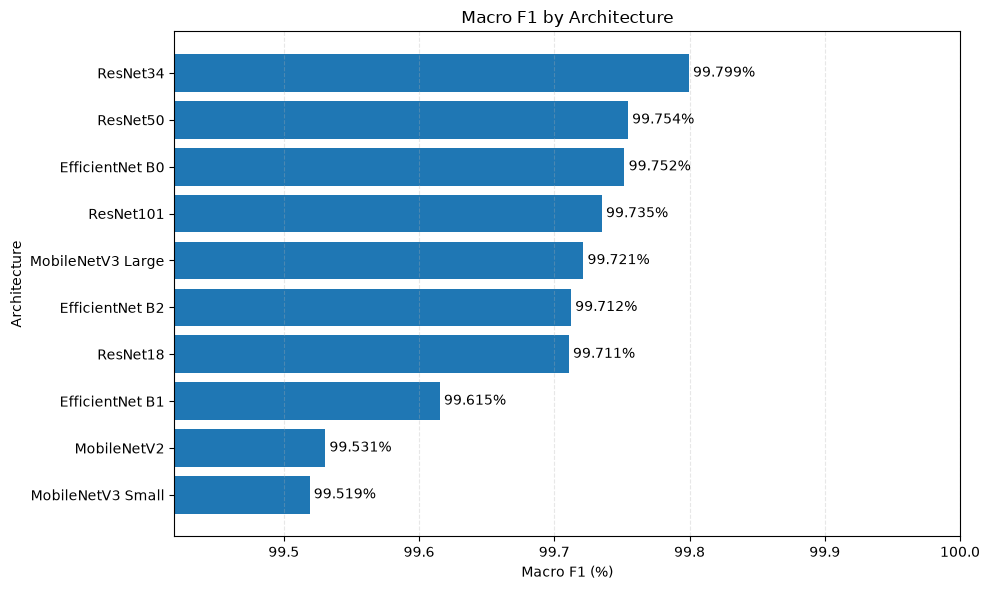

In [4]:
test_results = test_results.sort_values("Macro_F1")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(test_results["Model"], test_results["Macro_F1"])

ax.bar_label(bars, fmt="%.3f%%", padding=3)

ax.set_title("Macro F1 by Architecture")
ax.set_xlabel("Macro F1 (%)")
ax.set_ylabel("Architecture")

ax.set_xlim(test_results["Macro_F1"].min() - 0.1, 100)

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(route_graphs_test / "macro_f1_comparison.png", dpi=300,bbox_inches="tight")

plt.show()

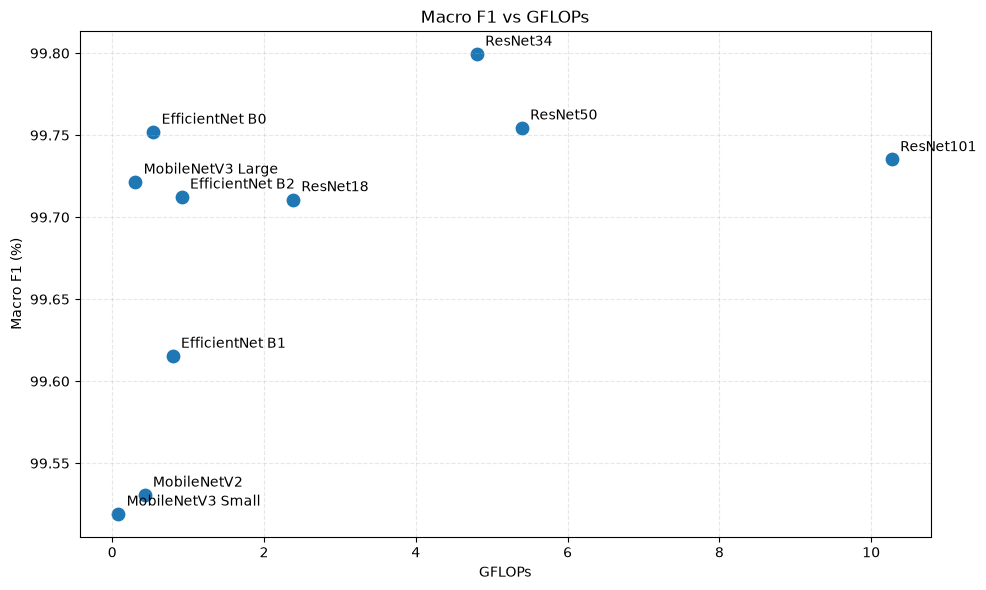

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(test_results["GFLOPs"], test_results["Macro_F1"], s=80)

for _, row in test_results.iterrows():
    ax.annotate(row["Model"], (row["GFLOPs"], row["Macro_F1"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("Macro F1 vs GFLOPs")

ax.set_xlabel("GFLOPs")

ax.set_ylabel("Macro F1 (%)")

ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(route_graphs_test / "f1_vs_gflops.png", dpi=300, bbox_inches="tight")

plt.show()

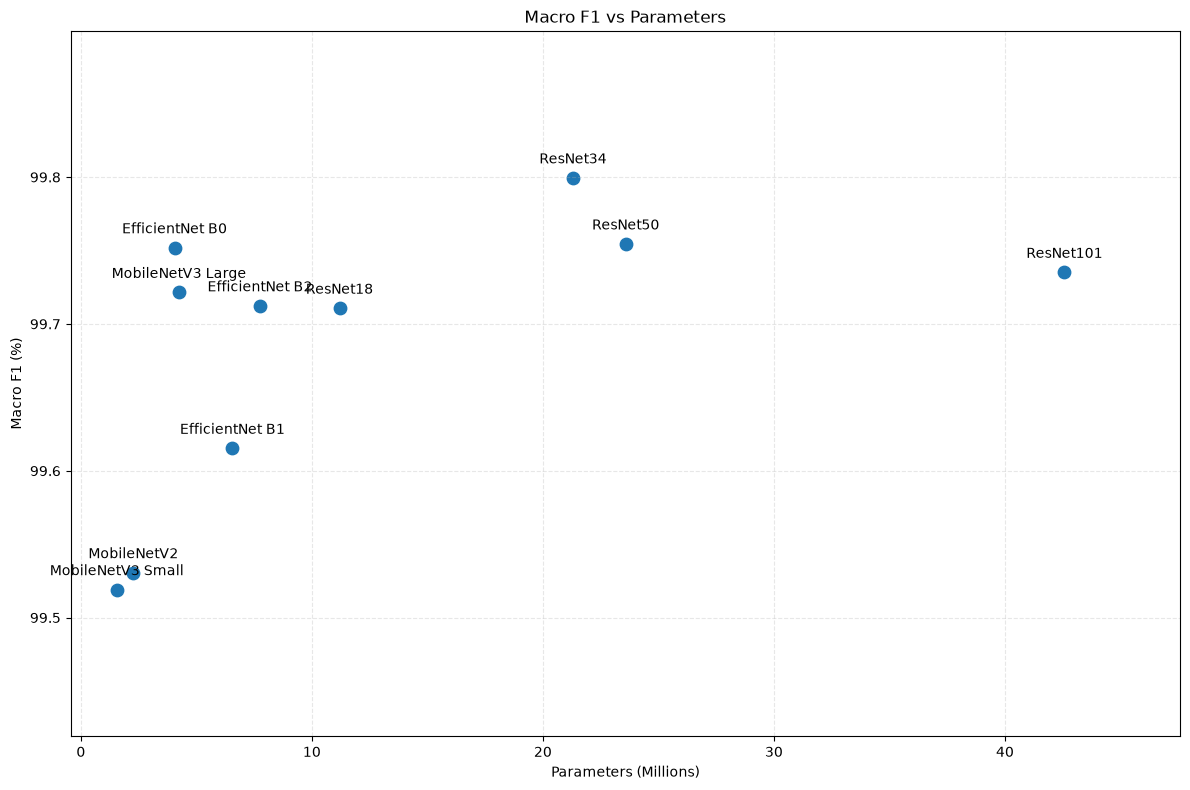

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(test_results["Parameters_M"], test_results["Macro_F1"], s=80)

for _, row in test_results.iterrows():
    ax.annotate(row["Model"], (row["Parameters_M"], row["Macro_F1"]), xytext=(0, 8), textcoords="offset points", ha="center", va="bottom")

ax.set_title("Macro F1 vs Parameters")

ax.set_xlabel("Parameters (Millions)")

ax.set_ylabel("Macro F1 (%)")

ax.set_xlim(test_results["Parameters_M"].min() - 2, test_results["Parameters_M"].max() + 5)

ax.set_ylim(test_results["Macro_F1"].min() - 0.1, test_results["Macro_F1"].max() + 0.1)

ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(route_graphs_test / "f1_vs_parameters.png", dpi=300, bbox_inches="tight")

plt.show()

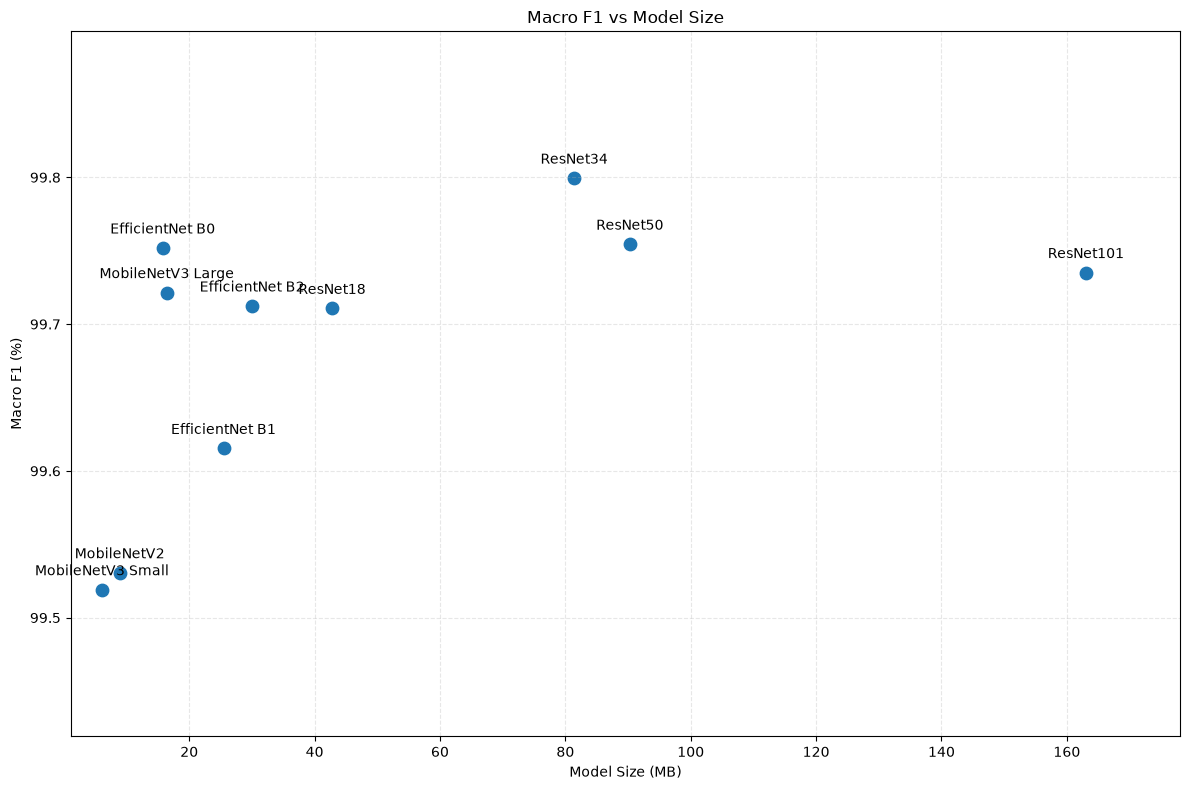

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(test_results["Model_Size_MB"], test_results["Macro_F1"], s=80)

for _, row in test_results.iterrows():
    ax.annotate(row["Model"], (row["Model_Size_MB"], row["Macro_F1"]), xytext=(0, 8), textcoords="offset points", ha="center", va="bottom")

ax.set_title("Macro F1 vs Model Size")

ax.set_xlabel("Model Size (MB)")

ax.set_ylabel("Macro F1 (%)")

ax.set_xlim(test_results["Model_Size_MB"].min() - 5, test_results["Model_Size_MB"].max() + 15)

ax.set_ylim(test_results["Macro_F1"].min() - 0.1, test_results["Macro_F1"].max() + 0.1)

ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(route_graphs_test / "f1_vs_model_size.png", dpi=300, bbox_inches="tight")

plt.show()

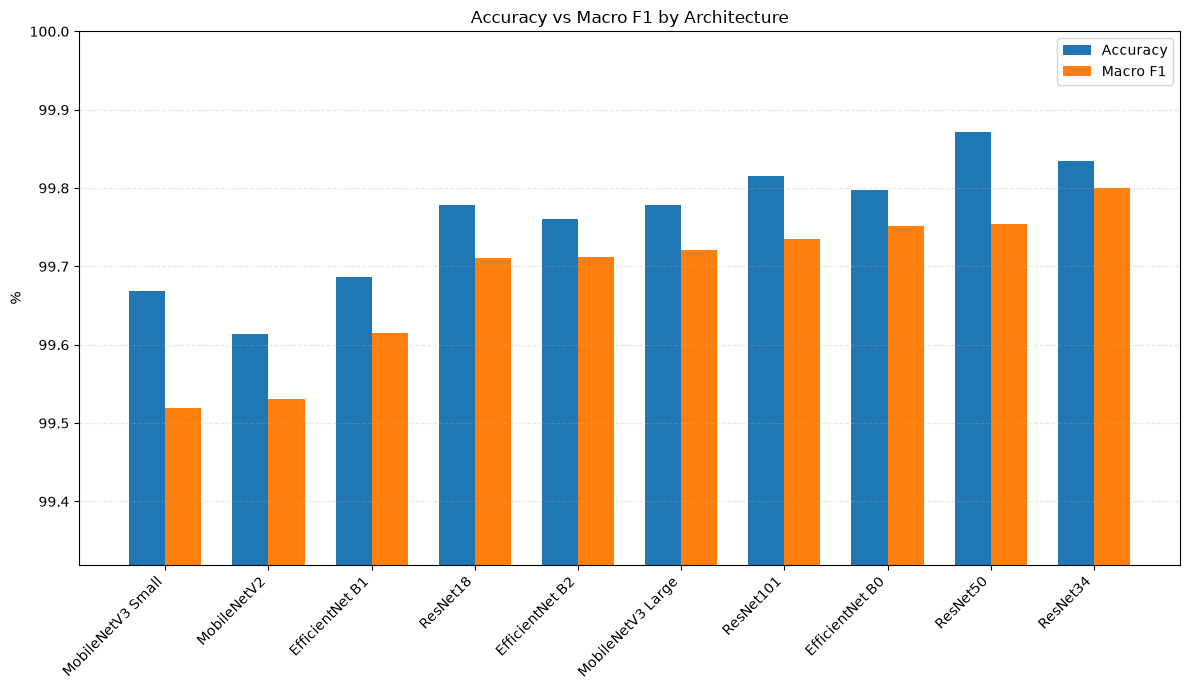

In [8]:
test_results_sorted = test_results.sort_values("Macro_F1")

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(test_results_sorted))
width = 0.35

ax.bar([i - width/2 for i in x], test_results_sorted["Accuracy"], width, label="Accuracy")
ax.bar([i + width/2 for i in x], test_results_sorted["Macro_F1"], width, label="Macro F1")

ax.set_xticks(x)
ax.set_xticklabels(test_results_sorted["Model"], rotation=45, ha="right")
ax.set_ylim(test_results_sorted["Macro_F1"].min() - 0.2, 100)
ax.set_title("Accuracy vs Macro F1 by Architecture")
ax.set_ylabel("%")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_test / "accuracy_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

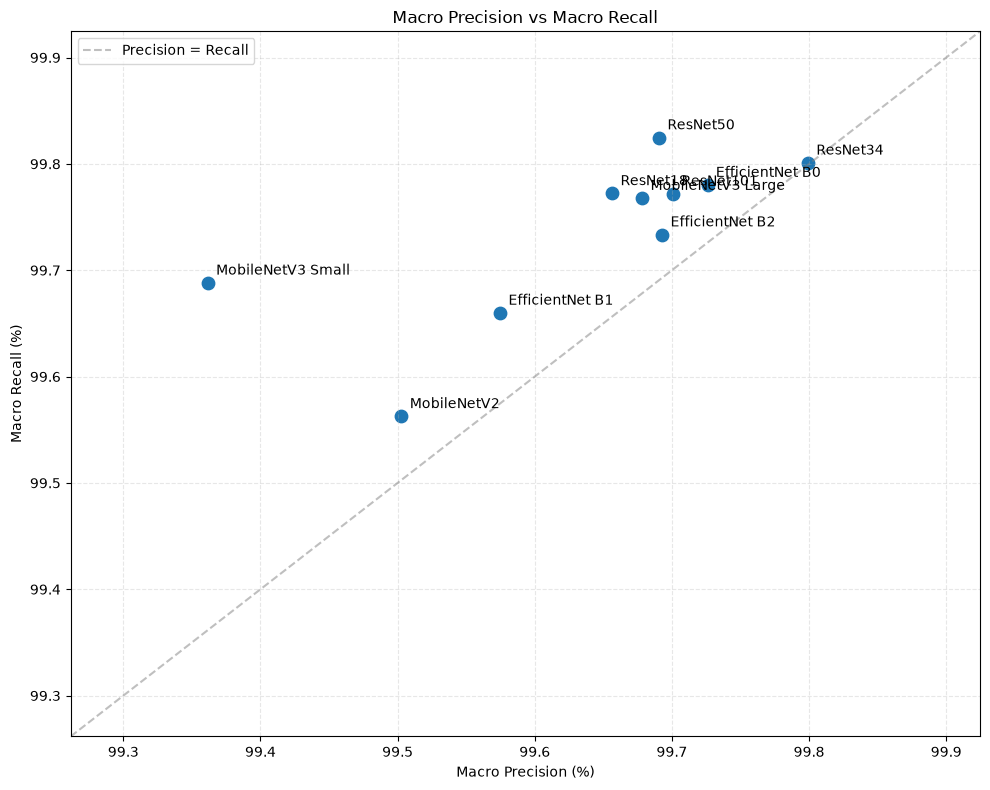

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(test_results["Macro_Precision"], test_results["Macro_Recall"], s=80)

for _, row in test_results.iterrows():
    ax.annotate(row["Model"], (row["Macro_Precision"], row["Macro_Recall"]), xytext=(6, 6), textcoords="offset points")

lims = [test_results[["Macro_Precision", "Macro_Recall"]].min().min() - 0.1,
        test_results[["Macro_Precision", "Macro_Recall"]].max().max() + 0.1]
ax.plot(lims, lims, linestyle="--", color="gray", alpha=0.5, label="Precision = Recall")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Macro Precision vs Macro Recall")
ax.set_xlabel("Macro Precision (%)")
ax.set_ylabel("Macro Recall (%)")
ax.legend()
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_test / "precision_vs_recall.png", dpi=300, bbox_inches="tight")
plt.show()

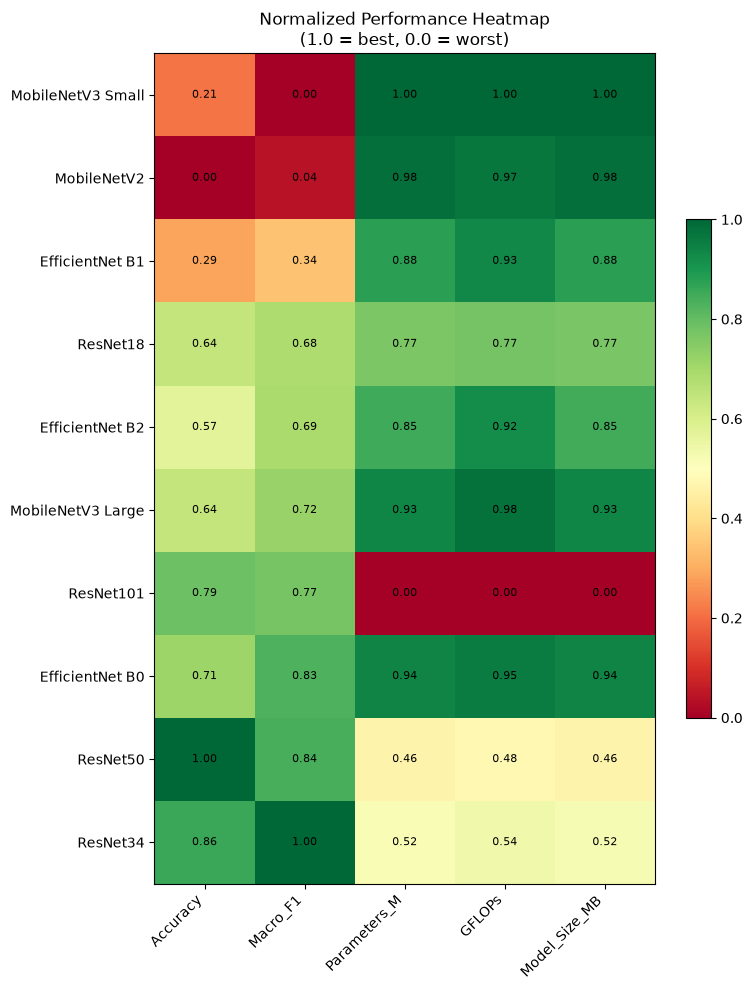

In [10]:
from matplotlib.colors import LinearSegmentedColormap

metrics = ["Accuracy", "Macro_F1", "Parameters_M", "GFLOPs", "Model_Size_MB"]
normalized = test_results[metrics].copy()

for col in ["Accuracy", "Macro_F1"]:
    normalized[col] = (normalized[col] - normalized[col].min()) / (normalized[col].max() - normalized[col].min())
for col in ["Parameters_M", "GFLOPs", "Model_Size_MB"]:
    normalized[col] = 1 - (normalized[col] - normalized[col].min()) / (normalized[col].max() - normalized[col].min())

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(normalized.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.set_yticks(range(len(test_results)))
ax.set_yticklabels(test_results["Model"])

for i in range(len(test_results)):
    for j in range(len(metrics)):
        ax.text(j, i, f"{normalized.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Normalized Performance Heatmap\n(1.0 = best, 0.0 = worst)")
fig.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout()
plt.savefig(route_graphs_test / "normalized_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
train_val_results = pd.read_csv("train_val_results.csv")
train_val_results

,Model,Best_Epoch,Train_Loss,Train_Accuracy,Train_Macro_Precision,Train_Macro_Recall,Train_Macro_F1,Val_Loss,Val_Accuracy,Val_Macro_Precision,Val_Macro_Recall,Val_Macro_F1
0,ResNet18,55.0,0.707548,99.907896,99.903039,99.907417,99.905176,0.711020,99.687959,99.557337,99.482408,99.507075
1,ResNet34,73.0,0.678019,99.988487,99.989005,99.987852,99.988420,0.681462,99.834802,99.783926,99.652242,99.713531
2,ResNet50,53.0,0.684625,99.983882,99.983873,99.985497,99.984675,0.687182,99.853157,99.826054,99.808537,99.816746
3,ResNet101,12.0,0.714386,99.806581,99.780805,99.784506,99.782510,0.710172,99.761380,99.707766,99.584954,99.639644
4,MobileNetV2,101.0,0.721066,99.806581,99.792964,99.782242,99.787541,0.716841,99.614537,99.558195,99.359619,99.451389
5,MobileNetV3 Small,110.0,0.729248,99.730595,99.715049,99.712530,99.713673,0.727698,99.247430,99.220367,99.043335,99.120345
6,MobileNetV3 Large,70.0,0.699268,99.917106,99.903932,99.915412,99.909609,0.700844,99.687959,99.670495,99.517694,99.590050
7,EfficientNet B0,76.0,0.706433,99.873357,99.865584,99.872955,99.869218,0.700410,99.743025,99.657033,99.521182,99.584403
8,EfficientNet B1,96.0,0.705905,99.776647,99.744550,99.752051,99.748214,0.694540,99.761380,99.704293,99.580923,99.635532
9,EfficientNet B2,58.0,0.705478,99.850330,99.826885,99.837886,99.832337,0.693464,99.706314,99.673925,99.492562,99.578531


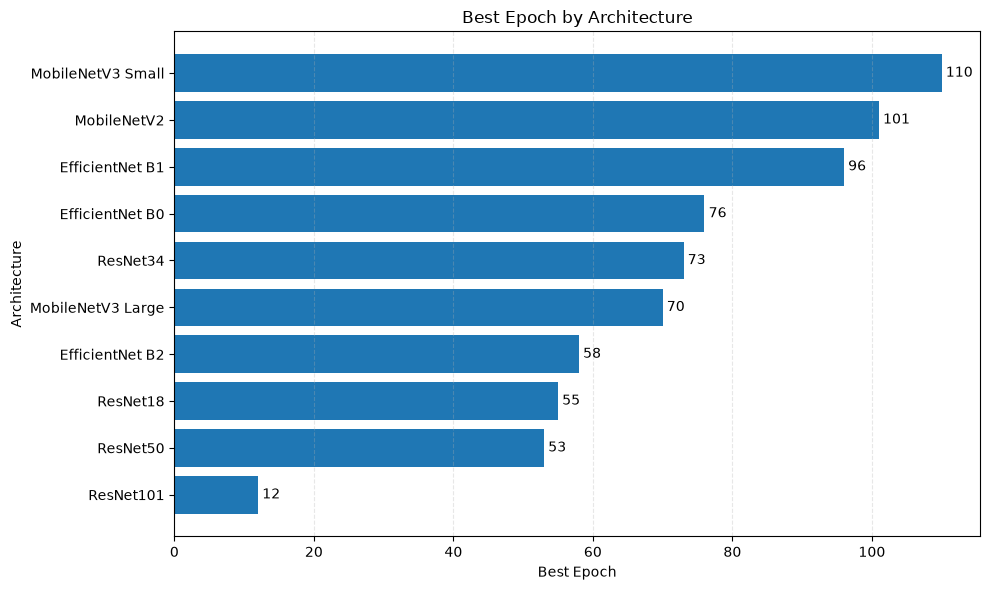

In [12]:
train_val_sorted = train_val_results.sort_values("Best_Epoch")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(train_val_sorted["Model"], train_val_sorted["Best_Epoch"])

ax.bar_label(bars, fmt="%.0f", padding=3)

ax.set_title("Best Epoch by Architecture")

ax.set_xlabel("Best Epoch")

ax.set_ylabel("Architecture")

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(route_graphs_train_val / "best_epoch_by_architecture.png",
            dpi=300, bbox_inches="tight")

plt.show()

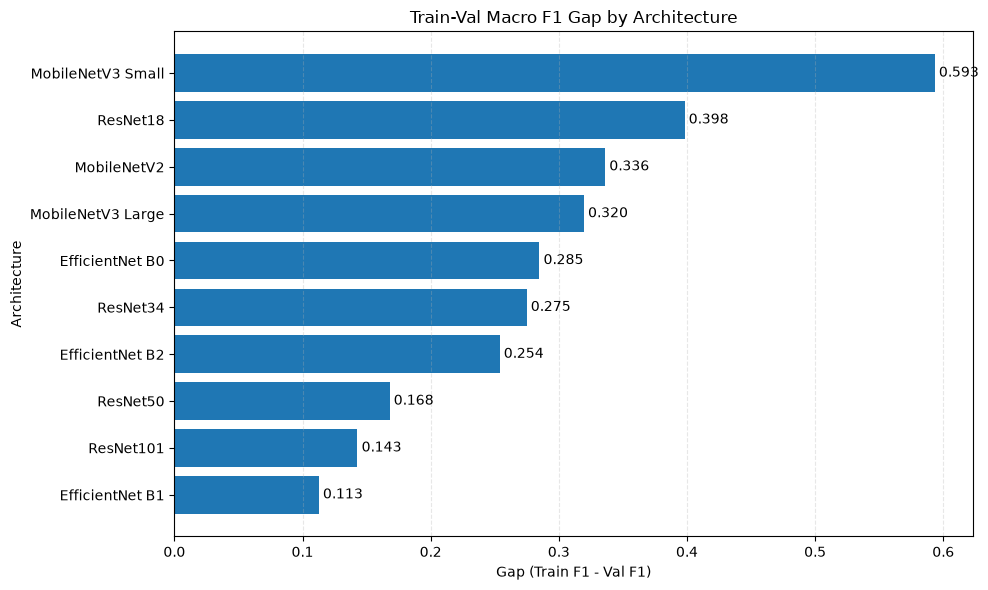

In [13]:
train_val_results["F1_Gap"] = train_val_results["Train_Macro_F1"] - train_val_results["Val_Macro_F1"]
gap_sorted = train_val_results.sort_values("F1_Gap")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(gap_sorted["Model"], gap_sorted["F1_Gap"])
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_title("Train-Val Macro F1 Gap by Architecture")
ax.set_xlabel("Gap (Train F1 - Val F1)")
ax.set_ylabel("Architecture")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "train_val_gap.png", dpi=300, bbox_inches="tight")
plt.show()

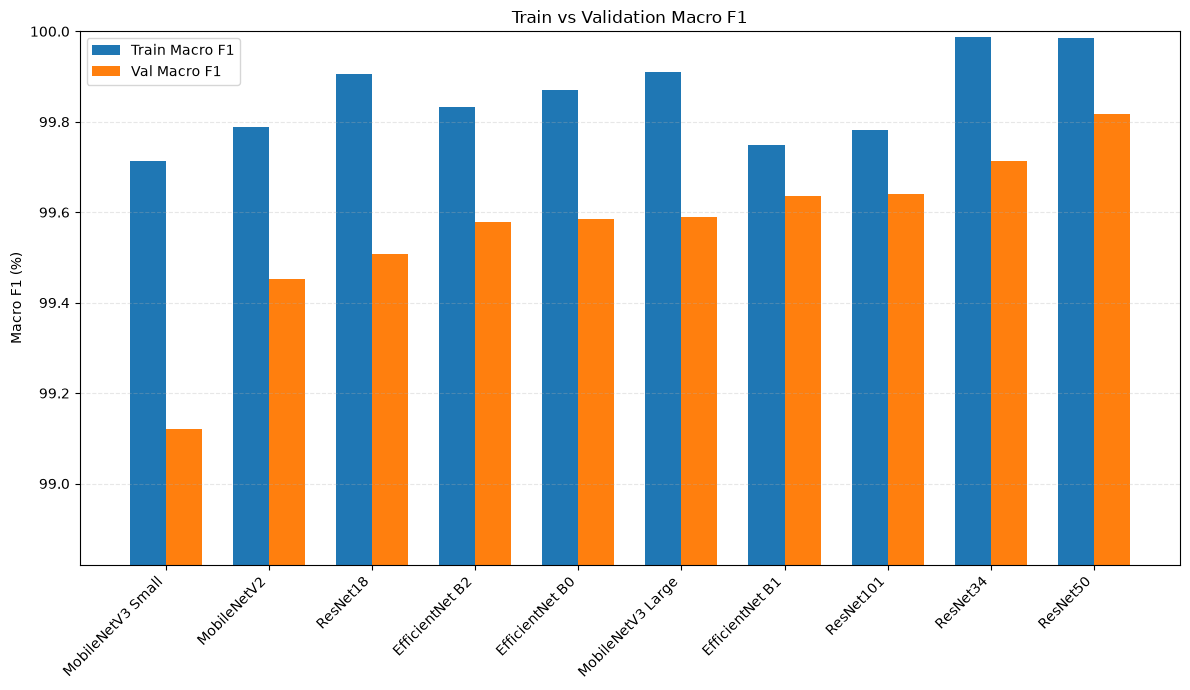

In [14]:
tv_sorted = train_val_results.sort_values("Val_Macro_F1")

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(tv_sorted))
width = 0.35

ax.bar([i - width/2 for i in x], tv_sorted["Train_Macro_F1"], width, label="Train Macro F1")
ax.bar([i + width/2 for i in x], tv_sorted["Val_Macro_F1"], width, label="Val Macro F1")

ax.set_xticks(x)
ax.set_xticklabels(tv_sorted["Model"], rotation=45, ha="right")
ax.set_ylim(tv_sorted["Val_Macro_F1"].min() - 0.3, 100)
ax.set_title("Train vs Validation Macro F1")
ax.set_ylabel("Macro F1 (%)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "train_vs_val_f1.png", dpi=300, bbox_inches="tight")
plt.show()

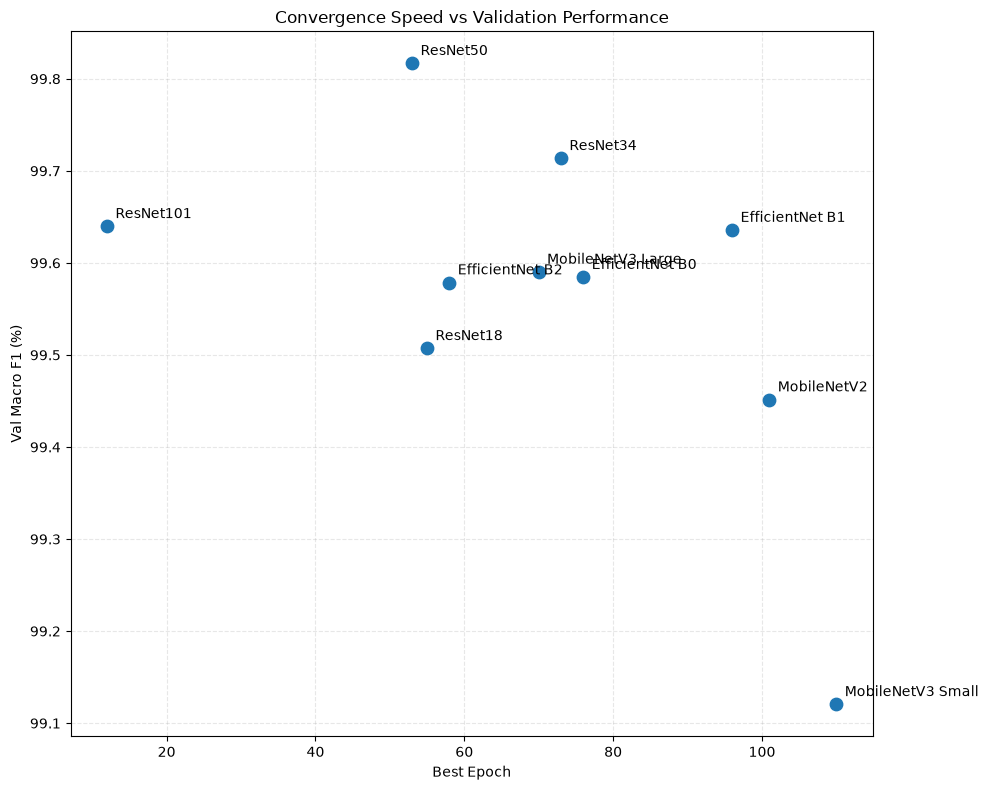

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(train_val_results["Best_Epoch"], train_val_results["Val_Macro_F1"], s=80)

for _, row in train_val_results.iterrows():
    ax.annotate(row["Model"], (row["Best_Epoch"], row["Val_Macro_F1"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("Convergence Speed vs Validation Performance")
ax.set_xlabel("Best Epoch")
ax.set_ylabel("Val Macro F1 (%)")
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "epoch_vs_val_f1.png", dpi=300, bbox_inches="tight")
plt.show()